# 03 — DQN on CartPole (pixel inputs) 🧪

This version builds the DQN state from rendered frames.

It's slower and more brittle than using the state vector, but it's a good exercise in:
- frame preprocessing (crop/resize/grayscale)
- CNN-based Q-network

The script saves:
- `dqn_cartpole_pixels/checkpoints/cartpole_pixel_dqn.pt`
- `dqn_cartpole_pixels/checkpoints/training_stats.json`


## Train

Tip: start with fewer episodes to check that everything runs.


In [1]:
import os, sys
from pathlib import Path
from typing import Optional

def find_project_root(start: Optional[Path] = None) -> Path:
    """Locate the project root so relative paths work no matter where Jupyter was launched."""
    start = (start or Path.cwd()).resolve()

    markers = [
        Path("dqn_cartpole_state") / "train.py",
        Path("dqn_cartpole_pixels") / "train.py",
        Path("q_learning_frozen_lake") / "train_q_learning.py",
    ]

    # 1) Search current directory and its parents
    for p in [start, *start.parents]:
        if (p / "requirements.txt").exists() and any((p / m).exists() for m in markers):
            return p
        if any((p / m).exists() for m in markers):
            return p

    # 2) Search downward (useful if you launched Jupyter ABOVE the project folder)
    for m in markers:
        matches = list(start.glob(f"**/{m.as_posix()}"))
        if matches:
            # m has 2 parts (dir/file), so parents[1] is the project root
            return matches[0].parents[len(m.parts) - 1]

    raise FileNotFoundError(
        "Could not find the project root.\n"
        "Tip: open a terminal, cd into the unzipped project folder, and run: jupyter notebook"
    )

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
print("Project root:", PROJECT_ROOT)
print("Python executable:", sys.executable)


Project root: /home/piotr/Documents/zajecia/RL/CS-RL/sutton_barto_classes/versions/RL_FrozenLake_Course_Pack_PL_v3/RL_FrozenLake_Course_Pack_PL/block2_policy_based/deeplizard_dqn_projects_with_notebooks_fixed_valid_v2
Python executable: /home/piotr/anaconda3/bin/python


In [2]:
import os, sys

# Pixel-based DQN needs rendering (rgb_array). On headless Linux this often fails unless
# we use a dummy SDL video driver. This does NOT open a window; it only enables frame capture.
os.environ.setdefault('SDL_VIDEODRIVER', 'dummy')
os.environ.setdefault('SDL_AUDIODRIVER', 'dummy')

# Dependency check (these are used only in the pixel version)
import importlib
for pkg in ['gymnasium','pygame','torch','torchvision','PIL']:
    try:
        importlib.import_module(pkg)
        print(f'OK: {pkg}')
    except Exception as e:
        print(f'MISSING/BROKEN: {pkg} -> {e}')

# Run a SHORT training first to generate stats quickly. Increase episodes once it works.
!{sys.executable} -m dqn_cartpole_pixels.train --episodes 50


OK: gymnasium
OK: pygame
OK: torch
OK: torchvision
OK: PIL
/home/piotr/anaconda3/lib/python3.8/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0
Using device: cpu
Ep    1 | reward=  11.0 | avg50=  11.0 | eps=1.000
Ep   20 | reward=  13.0 | avg50=  22.7 | eps=0.986
Ep   40 | reward=  29.0 | avg50=  22.5 | eps=0.972

Saved checkpoint: /home/piotr/Documents/zajecia/RL/CS-RL/sutton_barto_classes/versions/RL_FrozenLake_Course_Pack_PL_v3/RL_FrozenLake_Course_Pack_PL/block2_policy_based/deeplizard_dqn_projects_with_notebooks_fixed_valid_v2/dqn_cartpole_pixels/checkpoints/cartpole_pixel_dqn.pt


## Plot learning curves

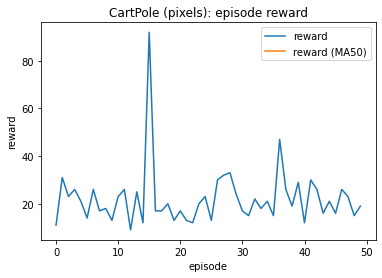

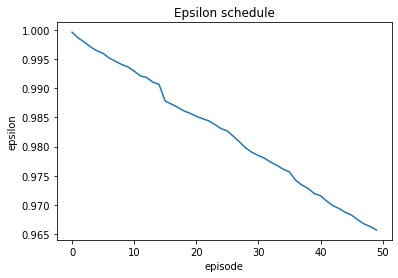

In [3]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


def moving_average(x, window=50):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode='valid')

stats_path = Path('dqn_cartpole_pixels/checkpoints/training_stats.json')
if not stats_path.exists():
    print('Stats file not found at:', stats_path.resolve())
    print('Run the training cell above first (and let it finish).')
    raise FileNotFoundError(stats_path)
stats = json.loads(stats_path.read_text())

rewards = stats['episode_rewards']
eps = stats['episode_epsilon']

plt.figure()
plt.plot(rewards, label='reward')
plt.plot(range(49, 49 + len(moving_average(rewards, 50))), moving_average(rewards, 50), label='reward (MA50)')
plt.title('CartPole (pixels): episode reward')
plt.xlabel('episode')
plt.ylabel('reward')
plt.legend()
plt.show()

plt.figure()
plt.plot(eps)
plt.title('Epsilon schedule')
plt.xlabel('episode')
plt.ylabel('epsilon')
plt.show()


## Play + record video (optional)

Recording may require extra dependencies (depending on your setup). If you get an error about video recording, try:

```bash
pip install moviepy imageio imageio-ffmpeg
```

Then run:


In [4]:
import sys
# !{sys.executable} -m dqn_cartpole_pixels.play --episodes 2 --record-dir videos
